## EDA: Temperatura diária (2014–2024, E-OBS)

Caminho do dataset:
`/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/temp_2014_2024_eobs.csv`

Objetivo: caracterizar a série (cobertura temporal, estatísticas, outliers e sazonalidade) e exportar resumos — tudo dentro de `EDA`.


In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

DATA_FILE = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/temp_2014_2024_eobs.csv")
assert DATA_FILE.exists(), f"CSV not found: {DATA_FILE}"

pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Using file: {DATA_FILE}")


Using file: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/temp_2014_2024_eobs.csv


### 2) Leitura do CSV, parsing de datas e criação de colunas úteis

#### 2.1 Explicação do código
- `parse_dates` para interpretar `Time` como `datetime`.
- Leitura com tipos `float32` para reduzir memória.
- Ordenação cronológica e renomeação (nomes explícitos).
- Colunas derivadas: `temp_mean_c`, `year`, `month`.
- `head`, `tail`, `info` para validação.


In [ ]:
parse_dates = ["Time"]
df = pd.read_csv(
    DATA_FILE,
    parse_dates=parse_dates,
    dtype={"tx": "float32", "tn": "float32", "lat": "float32", "long": "float32"},
)

df = df.sort_values("Time").reset_index(drop=True)

column_renames = {
    "Time": "date",
    "tx": "temp_max_c",
    "tn": "temp_min_c",
    "lat": "latitude",
    "long": "longitude",
}
df = df.rename(columns=column_renames)

# Colunas derivadas
df["temp_mean_c"] = df[["temp_max_c", "temp_min_c"]].mean(axis=1)
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
# Identificador de local (lat_long) arredondado para estabilidade
df["site_id"] = (
    df["latitude"].round(5).astype(str) + "_" + df["longitude"].round(5).astype(str)
)

print(df.head())
print(df.tail())
df.info()


        date  temp_max_c  temp_min_c  latitude  longitude  temp_mean_c  year  month
0 2014-01-01      15.780      11.920    38.550     -8.650       13.850  2014      1
1 2014-01-01      14.940      11.630    39.250     -8.950       13.285  2014      1
2 2014-01-01      15.580      11.850    38.850     -8.850       13.715  2014      1
3 2014-01-01      14.620      11.240    39.650     -8.950       12.930  2014      1
4 2014-01-01      14.850      10.440    38.750     -8.250       12.645  2014      1
             date  temp_max_c  temp_min_c  latitude  longitude  temp_mean_c  year  month
555925 2024-06-30      24.150      13.380    39.450     -8.350       18.765  2024      6
555926 2024-06-30      23.910      13.800    39.050     -8.850       18.855  2024      6
555927 2024-06-30      24.490      13.910    38.650     -8.850       19.200  2024      6
555928 2024-06-30      24.220      13.540    39.150     -8.550       18.880  2024      6
555929 2024-06-30      23.550      13.580    39.050

### 3) Cobertura temporal, dias em falta, duplicados e estatísticas

#### 3.1 Explicação do código
- Frequência diária esperada e `full_range`.
- `missing_dates` identifica lacunas.
- `describe` com percentis.
- Duplicados por `date`.


In [3]:
from pandas.tseries.frequencies import to_offset

start_date = df["date"].min()
end_date = df["date"].max()
expected_freq = to_offset("1D")

print(f"Start: {start_date:%Y-%m-%d}  End: {end_date:%Y-%m-%d}")
full_range = pd.date_range(start=start_date, end=end_date, freq=expected_freq)
missing_dates = full_range.difference(df["date"])
print(f"Missing days: {len(missing_dates)}")

numeric_cols = ["temp_max_c", "temp_min_c", "temp_mean_c"]
display(df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T)

dups = df[df.duplicated("date", keep=False)]
print(f"Duplicate timestamps: {dups.shape[0]}")
display(dups.head())


Start: 2014-01-01  End: 2024-06-30
Missing days: 0


,count,mean,std,min,1%,5%,50%,95%,99%,max
temp_max_c,555930.000,22.912,6.503,6.910,11.950,13.940,22.090,34.220,37.800,46.100
temp_min_c,555930.000,11.584,4.476,-4.420,1.080,3.880,11.770,18.280,20.250,28.680
temp_mean_c,555930.000,17.248,5.188,2.450,7.160,9.385,16.925,25.740,28.215,35.005


Duplicate timestamps: 555930


,date,temp_max_c,temp_min_c,latitude,longitude,temp_mean_c,year,month
0,2014-01-01,15.780,11.920,38.550,-8.650,13.850,2014,1
1,2014-01-01,14.940,11.630,39.250,-8.950,13.285,2014,1
2,2014-01-01,15.580,11.850,38.850,-8.850,13.715,2014,1
3,2014-01-01,14.620,11.240,39.650,-8.950,12.930,2014,1
4,2014-01-01,14.850,10.440,38.750,-8.250,12.645,2014,1


### 3.2) Localização dos pontos (coordenadas únicas)

#### 3.2.1 Explicação do código
- Conta o número de locais distintos (`latitude`,`longitude`).
- Resume por local: nº de registos, 1.º e último dia com observações.
- Guarda a tabela para uso posterior.


In [8]:
# Contagem de pontos únicos
unique_points = df[["latitude", "longitude"]].drop_duplicates().shape[0]
print(f"Unique measurement locations: {unique_points}")

# Resumo por localização
location_summary = (
    df.groupby(["latitude", "longitude"]).agg(
        n_obs=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        temp_mean_avg=("temp_mean_c", "mean")
    ).reset_index()
)

display(location_summary.head())

# Guardar para recursos
loc_out_dir = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/temperaturas/resources")
loc_out_dir.mkdir(parents=True, exist_ok=True)
location_summary.to_csv(loc_out_dir / "temp_location_summary.csv", index=False)
print(f"Saved location summary in: {loc_out_dir}")


Unique measurement locations: 145


,latitude,longitude,n_obs,first_date,last_date,temp_mean_avg
0,38.350,-8.750,3834,2014-01-01,2024-06-30,18.083
1,38.350,-8.650,3834,2014-01-01,2024-06-30,17.931
2,38.350,-8.550,3834,2014-01-01,2024-06-30,17.967
3,38.350,-8.450,3834,2014-01-01,2024-06-30,17.882
4,38.350,-8.350,3834,2014-01-01,2024-06-30,17.816


Saved location summary in: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/temperaturas/resources


### 4) Deteção de outliers (IQR e Z-score)

#### 4.1 Explicação do código
- IQR e Z-score para marcação de extremos.
- Combinação `OR` e criação de `is_outlier_*`.
- Amostra das primeiras ocorrências.


In [4]:
def detect_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    q1 = np.nanpercentile(series, 25)
    q3 = np.nanpercentile(series, 75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return (series < lower) | (series > upper)


def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    mu = np.nanmean(series)
    sigma = np.nanstd(series)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(False, index=series.index)
    z = (series - mu) / sigma
    return z.abs() > threshold

for col in ["temp_max_c", "temp_min_c", "temp_mean_c"]:
    iqr_flags = detect_outliers_iqr(df[col])
    z_flags = detect_outliers_zscore(df[col])
    df[f"is_outlier_{col}"] = iqr_flags | z_flags
    print(f"{col}: {df[f'is_outlier_{col}'].sum()} possíveis outliers")

cols = ["date", "temp_max_c", "temp_min_c", "temp_mean_c"] + [c for c in df.columns if c.startswith("is_outlier_")]
display(df.loc[df.filter(like="is_outlier_").any(axis=1), cols].head(10))


temp_max_c: 247 possíveis outliers
temp_min_c: 703 possíveis outliers
temp_mean_c: 239 possíveis outliers


,date,temp_max_c,temp_min_c,temp_mean_c,is_outlier_temp_max_c,is_outlier_temp_min_c,is_outlier_temp_mean_c
58332,2015-02-07,10.370,-1.950,4.210,False,True,False
58365,2015-02-07,10.170,-1.850,4.160,False,True,False
135579,2016-07-24,34.120,25.060,29.590,False,True,False
135581,2016-07-24,34.190,25.030,29.610,False,True,False
137499,2016-08-06,42.630,17.850,30.240,True,False,False
137500,2016-08-06,42.820,17.800,30.310,True,False,False
137504,2016-08-06,43.180,17.370,30.275,True,False,False
137511,2016-08-06,42.660,17.700,30.180,True,False,False
137536,2016-08-06,42.950,17.570,30.260,True,False,False
137599,2016-08-06,42.940,16.930,29.935,True,False,False


### 5) Gráficos: série temporal e distribuição mensal

#### 5.1 Explicação do código
- Três subplots com `temp_max_c`, `temp_min_c`, `temp_mean_c`.
- Outliers assinalados com pontos pretos.
- Boxplots mensais (`seaborn`).


### 5A) Gráficos agregados (todas as localidades)
Os gráficos seguintes usam TODAS as observações (todas as coordenadas).


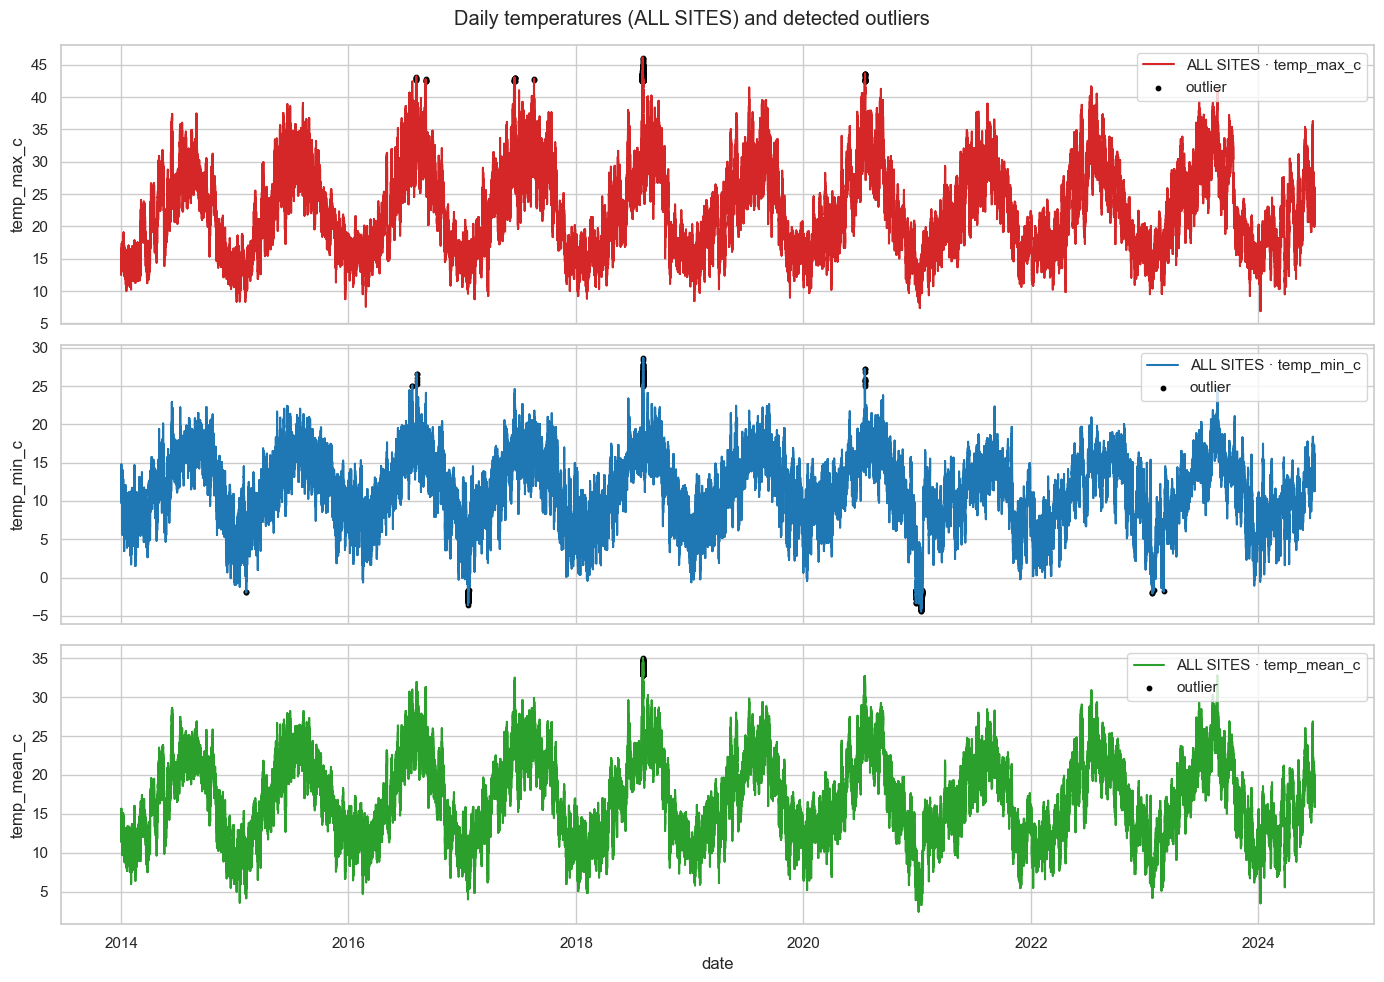

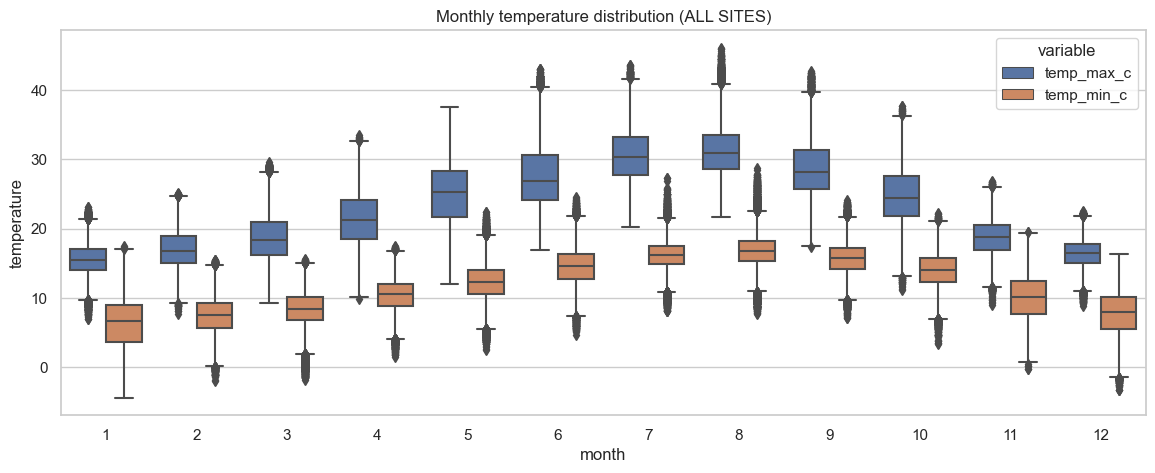

In [ ]:
# Gráficos agregados (todos os locais)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for idx, col in enumerate(["temp_max_c", "temp_min_c", "temp_mean_c"]):
    axes[idx].plot(df["date"], df[col], label=f"ALL SITES · {col}", color=["tab:red","tab:blue","tab:green"][idx])
    axes[idx].scatter(df.loc[df[f"is_outlier_{col}"] , "date"], df.loc[df[f"is_outlier_{col}"] , col],
                      color="black", s=10, label="outlier")
    axes[idx].set_ylabel(col)
    axes[idx].legend(loc="upper right")
axes[-1].set_xlabel("date")
fig.suptitle("Daily temperatures (ALL SITES) and detected outliers")
plt.tight_layout()
plt.show()

if sns is not None:
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=df.melt(id_vars=["year", "month"], value_vars=["temp_max_c", "temp_min_c"],
                             var_name="variable", value_name="temperature"),
                x="month", y="temperature", hue="variable")
    plt.title("Monthly temperature distribution (ALL SITES)")
    plt.show()


### 5B) Gráficos por localidade específica
Escolha um `site_id` para filtrar os gráficos para uma localização concreta.


In [11]:
# Visualização por localidade específica, com seletor
# Garante existência de site_id caso a célula anterior não tenha sido executada
if "site_id" not in df.columns:
    df["site_id"] = (
        df["latitude"].round(5).astype(str) + "_" + df["longitude"].round(5).astype(str)
    )

unique_sites = sorted(df["site_id"].unique())
print(f"Total sites: {len(unique_sites)}")

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False


def plot_site(selected_site: str) -> None:
    df_site = df[df["site_id"] == selected_site].copy()
    if df_site.empty:
        print(f"No data for site_id={selected_site}")
        return
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for idx, col in enumerate(["temp_max_c", "temp_min_c", "temp_mean_c"]):
        axes[idx].plot(df_site["date"], df_site[col], label=f"{selected_site} · {col}",
                       color=["tab:red","tab:blue","tab:green"][idx])
        axes[idx].scatter(
            df_site.loc[df_site[f"is_outlier_{col}"] , "date"],
            df_site.loc[df_site[f"is_outlier_{col}"] , col],
            color="black", s=10, label="outlier"
        )
        axes[idx].set_ylabel(col)
        axes[idx].legend(loc="upper right")
    axes[-1].set_xlabel("date")
    fig.suptitle(f"Daily temperatures ({selected_site}) and detected outliers")
    plt.tight_layout()
    plt.show()


if HAS_WIDGETS:
    site_dropdown = widgets.Dropdown(options=unique_sites, value=unique_sites[0], description="site_id:")
    output = widgets.Output()

    def on_change(change):
        if change.get("name") == "value":
            with output:
                clear_output(wait=True)
                plot_site(change["new"]) 

    site_dropdown.observe(on_change, names="value")
    display(site_dropdown)
    with output:
        plot_site(site_dropdown.value)
    display(output)
else:
    # Fallback sem widgets: altere 'selected_site' e volte a executar a célula
    selected_site = unique_sites[0]
    print(f"Widgets indisponíveis. A mostrar site: {selected_site}. Para outro site, mude 'selected_site' e re-execute.")
    plot_site(selected_site)


Total sites: 145


Dropdown(description='site_id:', options=('38.35_-8.25', '38.35_-8.35', '38.35_-8.45', '38.35_-8.55', '38.35_-…

Output()

### 6) Sazonalidade: climatologia diária e anomalias

#### 6.1 Explicação do código
- Climatologia por dia-do-ano (média e σ) para `temp_mean_c`.
- Anomalia = `temp_mean_c - clim_mean`.
- Gráficos: série com envelope ±1σ e anomalia.


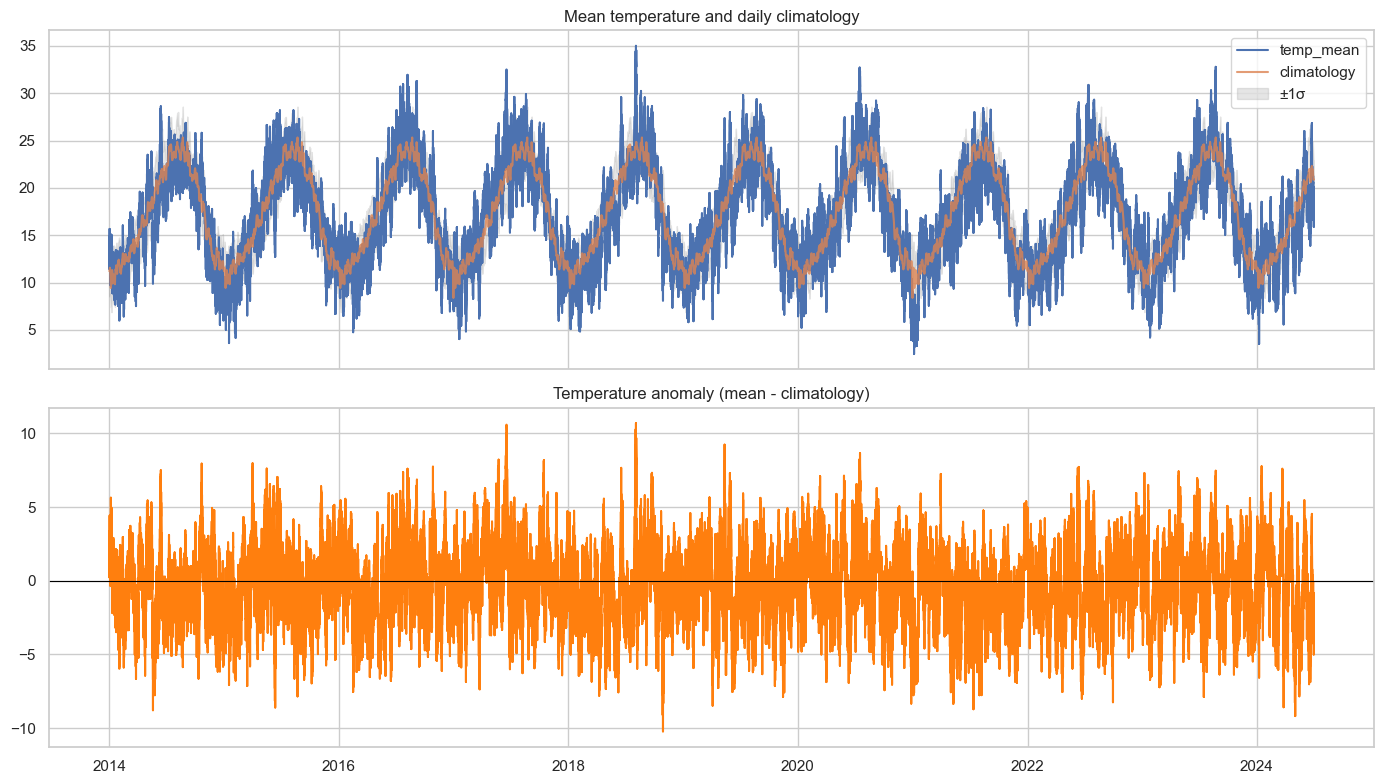

In [6]:
clim = (
    df.assign(doy=df["date"].dt.dayofyear)
      .groupby("doy")["temp_mean_c"].agg(["mean", "std"]).rename(columns={"mean": "clim_mean", "std": "clim_std"})
)

df = df.assign(doy=df["date"].dt.dayofyear).merge(clim, left_on="doy", right_index=True, how="left")
df["anomaly"] = df["temp_mean_c"] - df["clim_mean"]

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax[0].plot(df["date"], df["temp_mean_c"], label="temp_mean")
ax[0].plot(df["date"], df["clim_mean"], label="climatology", alpha=0.8)
ax[0].fill_between(df["date"], df["clim_mean"]-df["clim_std"], df["clim_mean"]+df["clim_std"],
                   color="gray", alpha=0.2, label="±1σ")
ax[0].legend()
ax[0].set_title("Mean temperature and daily climatology")

ax[1].plot(df["date"], df["anomaly"], color="tab:orange")
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("Temperature anomaly (mean - climatology)")
plt.tight_layout()
plt.show()


### 7) Export de tabelas resumo (dentro de EDA)

#### 7.1 Explicação do código
- Estatísticas resumo e médias mensais.
- Export para `EDA /scripts/temperaturas/resources/`.


In [ ]:
summary_stats = df[["temp_max_c", "temp_min_c", "temp_mean_c"]].describe().T
monthly_means = df.groupby(["year", "month"])[["temp_max_c", "temp_min_c", "temp_mean_c"]].mean().reset_index()

# Adiciona metadados de localização ao resumo
unique_points = df[["latitude", "longitude"]].drop_duplicates().shape[0]
summary_stats.loc["meta_unique_points", ["count", "mean"]] = [unique_points, np.nan]

display(summary_stats)
display(monthly_means.head(12))

out_dir = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/temperaturas/resources")
out_dir.mkdir(parents=True, exist_ok=True)
summary_stats.to_csv(out_dir / "temp_summary_stats.csv")
monthly_means.to_csv(out_dir / "temp_monthly_means.csv", index=False)
print(f"Saved summaries in: {out_dir}")


,count,mean,std,min,25%,50%,75%,max
temp_max_c,555930.000,22.912,6.503,6.910,17.400,22.090,27.900,46.100
temp_min_c,555930.000,11.584,4.476,-4.420,8.390,11.770,15.090,28.680
temp_mean_c,555930.000,17.248,5.188,2.450,13.085,16.925,21.375,35.005


,year,month,temp_max_c,temp_min_c,temp_mean_c
0,2014,1,14.762,8.725,11.743
1,2014,2,14.850,7.488,11.169
2,2014,3,18.102,8.505,13.304
3,2014,4,20.701,11.194,15.947
4,2014,5,24.479,12.521,18.500
5,2014,6,26.030,14.971,20.500
6,2014,7,28.530,16.203,22.366
7,2014,8,28.920,16.596,22.758
8,2014,9,26.349,17.088,21.719
9,2014,10,24.540,15.627,20.083


Saved summaries in: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/temperaturas/resources
